# 🏥 Fine-Tuning BART-Large-CNN for Medical SOAP Chat Summarization

**Author:** Rawhatur Rabbi

**Contact:** rawhatur.rabbi@gmail.com, +8801937490471

**Date:** October 2025


---


## Project Overview

This notebook demonstrates fine-tuning of Facebook's `bart-large-cnn` model for summarizing medical dialogues into concise, accurate, and well-structured SOAP (Subjective, Objective, Assessment, Plan) notes. The workflow covers data preparation, baseline evaluation, model training, evaluation, and deployment-ready packaging, following all requirements in the assignment brief.


## Table of Contents

1. [Environment & Setup](#environment-setup)
2. [Data Loading & Preprocessing](#data-loading-preprocessing)
3. [Baseline Model Evaluation](#baseline-model-evaluation)
4. [Tokenization & Preparation](#tokenization-preparation)
5. [Training Configuration](#training-configuration)
6. [Model Training](#model-training)
7. [Model Saving & Loading](#model-saving-loading)
8. [Loaded Model Testing](#loaded-model-testing)
9. [Predictions & Metrics](#predictions-metrics)
10. [Analysis & Visualization](#analysis-visualization)
11. [Before/After Comparison](#before-after-comparison)
12. [Deployment Guide](#deployment-guide)


---


> **Assignment Requirements:**
> - Use the provided SOAP medical chat dataset for training/evaluation
> - Show baseline and fine-tuned model performance
> - Evaluate with ROUGE/BLEU and qualitative analysis
> - Save and document the model for deployment (API/Cloud)
> - Provide clear, professional documentation and code organization


### Dataset
- **Train:** `SOAP_Assessment_Data/medical_dialogue_train.csv`
- **Test:** `SOAP_Assessment_Data/medical_dialogue_test.xlsx`
- **Validation:** `SOAP_Assessment_Data/medical_dialogue_validation.xlsx`
- **Format:** Columns: `dialogue` (input), `soap` (target summary)

### Environment Requirements
- Python 3.10+
- PyTorch 2.0+ (with CUDA if GPU available)
- Hugging Face Transformers, Datasets, Accelerate
- See `requirements.txt` for complete list and `setup_venv.sh` for automated setup

---

## 1. Environment Setup & Configuration


In [1]:
# ============================================================================
# IMPORTS
# ============================================================================

# Standard library
import sys
import os
import gc
from typing import Dict, List, Optional

# Data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Deep learning
import torch

# Hugging Face ecosystem
from datasets import load_dataset, Dataset, DatasetDict
from transformers import (
    AutoModelForSeq2SeqLM,
    AutoTokenizer,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    pipeline
)

# Evaluation metrics
import evaluate
import nltk

# Download required NLTK data
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)

# ============================================================================
# ENVIRONMENT CONFIGURATION
# ============================================================================

print("="*70)
print("ENVIRONMENT CONFIGURATION")
print("="*70)

print(f"Python version: {sys.version.split()[0]}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"Total GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Set global device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\n✓ Using device: {DEVICE.upper()}")
print("="*70)

# Set style for plots
plt.style.use('default')
sns.set_palette("husl")

/home/RA001/Documents/Assesment FInal LLM finetuning/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ENVIRONMENT CONFIGURATION
Python version: 3.10.18
PyTorch version: 2.9.0+cu128
CUDA available: True
CUDA version: 12.8
CUDA device: NVIDIA GeForce RTX 4090
Total GPU memory: 25.25 GB

✓ Using device: CUDA


## 2. Model and Training Configuration


In [2]:
# ============================================================================
# CONFIGURATION PARAMETERS
# ============================================================================

# Model configuration
MODEL_NAME = "facebook/bart-large-cnn"
MAX_INPUT_LENGTH = 1024  # Maximum dialogue length
MAX_TARGET_LENGTH = 900  # Maximum SOAP summary length

# Training configuration
BATCH_SIZE = 4  # Reduced for memory efficiency
GRADIENT_ACCUMULATION_STEPS = 16  # Effective batch size = 16
LEARNING_RATE = 5e-5
NUM_EPOCHS = 5
WARMUP_STEPS = 500
WEIGHT_DECAY = 0.01

# Generation parameters
GEN_MAX_LENGTH = 900
GEN_MIN_LENGTH = 150
GEN_NUM_BEAMS = 4
GEN_LENGTH_PENALTY = 1.5

# Paths
OUTPUT_DIR = "./bart-soap-finetuned"
CHECKPOINT_DIR = "./checkpoints"

print("Configuration:")
print(f"  Model: {MODEL_NAME}")
print(f"  Max input length: {MAX_INPUT_LENGTH}")
print(f"  Max target length: {MAX_TARGET_LENGTH}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Effective batch size: {BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Epochs: {NUM_EPOCHS}")

Configuration:
  Model: facebook/bart-large-cnn
  Max input length: 1024
  Max target length: 900
  Batch size: 4
  Effective batch size: 64
  Learning rate: 5e-05
  Epochs: 5


## 3. Data Loading & Exploration

### 3.1 Load Dataset

Load the medical SOAP dialogue dataset from local CSV and Excel files in the `SOAP_Assessment_Data/` folder. The dataset contains:
- **Training set**: `medical_dialogue_train.csv` (main training data)
- **Test set**: `medical_dialogue_test.xlsx` (holdout evaluation)
- **Validation set**: `medical_dialogue_validation.xlsx` (hyperparameter tuning)

Each file contains two columns:
- `dialogue`: Medical conversation between doctor and patient
- `soap`: Target SOAP note summary

In [3]:
import pandas as pd
from datasets import Dataset 

# Load data files
print("Loading local dataset files...")
print("="*70)

df_train = pd.read_csv('./SOAP_Assessment_Data/medical_dialogue_train.csv')
df_test = pd.read_excel('./SOAP_Assessment_Data/medical_dialogue_test.xlsx')
df_val = pd.read_excel('./SOAP_Assessment_Data/medical_dialogue_validation.xlsx')

print(f"✓ Loaded training set: {len(df_train)} samples")
print(f"✓ Loaded test set: {len(df_test)} samples")
print(f"✓ Loaded validation set: {len(df_val)} samples")

# Clean data - remove rows with missing values
df_train = df_train.dropna()
df_test = df_test.dropna()
df_val = df_val.dropna()

print(f"\nAfter cleaning:")
print(f"✓ Training set: {len(df_train)} samples")
print(f"✓ Test set: {len(df_test)} samples")
print(f"✓ Validation set: {len(df_val)} samples")
print("="*70)

Loading local dataset files...
✓ Loaded training set: 9250 samples
✓ Loaded test set: 250 samples
✓ Loaded validation set: 500 samples

After cleaning:
✓ Training set: 9250 samples
✓ Test set: 250 samples
✓ Validation set: 500 samples
✓ Loaded training set: 9250 samples
✓ Loaded test set: 250 samples
✓ Loaded validation set: 500 samples

After cleaning:
✓ Training set: 9250 samples
✓ Test set: 250 samples
✓ Validation set: 500 samples


### 3.2 Convert to Hugging Face Dataset Format

Convert the pandas DataFrames into Hugging Face `Dataset` objects and combine them into a `DatasetDict`. This format is optimized for:
- Memory-efficient data loading during training
- Seamless integration with Transformers library
- Fast tokenization and batching operations

In [4]:
import pandas as pd
from datasets import Dataset, DatasetDict

print("Converting DataFrames to Hugging Face Dataset format...")

# Convert DataFrames to Hugging Face Datasets
dataset_train = Dataset.from_pandas(df_train.reset_index(drop=True))
dataset_test = Dataset.from_pandas(df_test.reset_index(drop=True))
dataset_val = Dataset.from_pandas(df_val.reset_index(drop=True))

# Create DatasetDict for easy access to all splits
dataset_soap = DatasetDict({
    'train': dataset_train,
    'test': dataset_test,
    'validation': dataset_val
})

print("\n" + "="*70)
print("Dataset Structure:")
print("="*70)
print(dataset_soap)
print("="*70)

# Verify columns
print(f"\nColumns: {dataset_soap['train'].column_names}")
print(f"Expected: ['dialogue', 'soap']")
print("✓ Dataset ready for tokenization and training!")

Converting DataFrames to Hugging Face Dataset format...

Dataset Structure:
DatasetDict({
    train: Dataset({
        features: ['dialogue', 'soap'],
        num_rows: 9250
    })
    test: Dataset({
        features: ['dialogue', 'soap'],
        num_rows: 250
    })
    validation: Dataset({
        features: ['dialogue', 'soap'],
        num_rows: 500
    })
})

Columns: ['dialogue', 'soap']
Expected: ['dialogue', 'soap']
✓ Dataset ready for tokenization and training!


In [5]:
# Display sample data
print("Sample example from training set:")
print("="*70)
sample = dataset_soap['train'][0]
print(f"DIALOGUE:\n{sample['dialogue'][:500]}...\n")
print(f"SOAP SUMMARY:\n{sample['soap']}\n")
print("="*70)

# Display first few examples
pd.DataFrame(dataset_soap['train'][:5])

Sample example from training set:
DIALOGUE:
Doctor: Hello, how can I help you today?
Patient: My son has been having some issues with speech and development. He's 13 years old now.
Doctor: I see. Can you tell me more about his symptoms? Does he have any issues with muscle tone or hypotonia?
Patient: No, he doesn't have hypotonia. But he has mild to moderate speech and developmental delay, and he's been diagnosed with attention deficit disorder.
Doctor: Thank you for sharing that information. We'll run some tests, including an MRI, to get ...

SOAP SUMMARY:
S: The patient's mother reports that her 13-year-old son has mild to moderate speech and developmental delays and has been diagnosed with attention deficit disorder. She denies any issues with muscle tone or hypotonia. The patient also exhibits certain physical characteristics, including retrognathia, mild hypertelorism, an elongated philtrum, thin upper lip, broad and short hands, mild syndactyly of the second and third toes, and a 

,dialogue,soap
0,"Doctor: Hello, how can I help you today?\nPati...",S: The patient's mother reports that her 13-ye...
1,"Doctor: Hello, what brings you in today?\nPati...","S: The patient, a 21-month-old male, presented..."
2,"Doctor: Hello, how can I help you today?\nPati...","S: Patient reports experiencing fatigue, night..."
3,"Doctor: Hello, Patient D. How are you feeling ...","S: Patient D, a 60-year-old African American m..."
4,"Doctor: Hello, I see that you have a history o...","S: The patient, a married woman with a 7-year ..."


Dialogue lengths - Mean: 414.9, Median: 420.0, Max: 604
SOAP lengths - Mean: 246.4, Median: 246.0, Max: 398


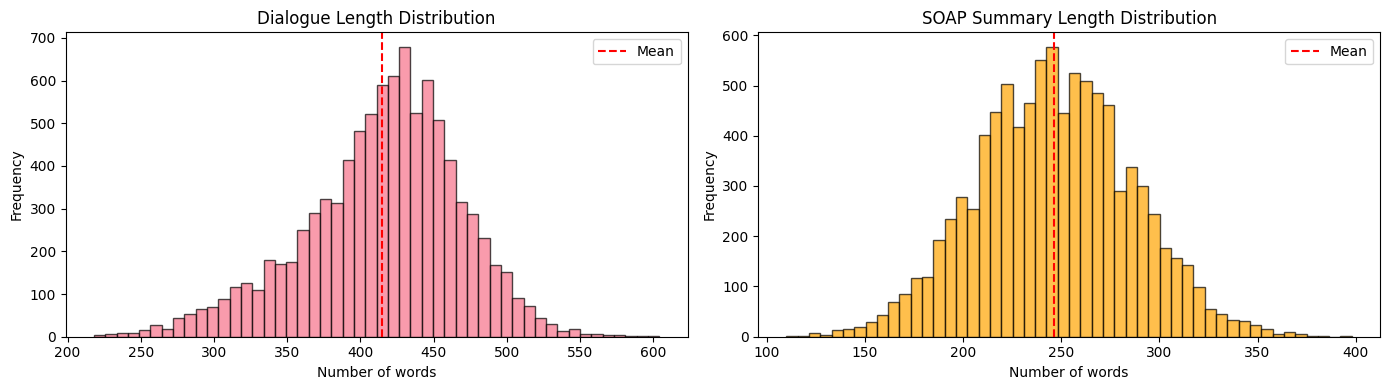

In [6]:
# Analyze text lengths
train_data = dataset_soap['train']

dialogue_lengths = [len(x.split()) for x in train_data['dialogue']]
soap_lengths = [len(x.split()) for x in train_data['soap']]

print(f"Dialogue lengths - Mean: {np.mean(dialogue_lengths):.1f}, "
      f"Median: {np.median(dialogue_lengths):.1f}, "
      f"Max: {np.max(dialogue_lengths)}")
print(f"SOAP lengths - Mean: {np.mean(soap_lengths):.1f}, "
      f"Median: {np.median(soap_lengths):.1f}, "
      f"Max: {np.max(soap_lengths)}")

# Visualize distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(dialogue_lengths, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of words')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Dialogue Length Distribution')
axes[0].axvline(np.mean(dialogue_lengths), color='red', linestyle='--', label='Mean')
axes[0].legend()

axes[1].hist(soap_lengths, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Number of words')
axes[1].set_ylabel('Frequency')
axes[1].set_title('SOAP Summary Length Distribution')
axes[1].axvline(np.mean(soap_lengths), color='red', linestyle='--', label='Mean')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Data Preprocessing & Tokenization

Prepare the data for fine-tuning by tokenizing dialogues and SOAP summaries.

In [7]:
# Initialize tokenizer
print("Initializing tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Tokenizer: {tokenizer.__class__.__name__}")
print(f"Vocabulary size: {tokenizer.vocab_size}")
print(f"Model max length: {tokenizer.model_max_length}")

Initializing tokenizer...
Tokenizer: BartTokenizerFast
Vocabulary size: 50265
Model max length: 1000000000000000019884624838656
Tokenizer: BartTokenizerFast
Vocabulary size: 50265
Model max length: 1000000000000000019884624838656


In [8]:
def preprocess_function(examples):
    """
    Tokenize dialogues and SOAP summaries for training.
    
    Args:
        examples: Batch of examples from dataset
        
    Returns:
        Dictionary with tokenized inputs and labels
    """
    # Tokenize inputs (dialogues)
    model_inputs = tokenizer(
        examples['dialogue'],
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding='max_length'
    )
    
    # Tokenize targets (SOAP summaries)
    labels = tokenizer(
        examples['soap'],
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
        padding='max_length'
    )
    
    # Replace padding token id with -100 so it's ignored in loss calculation
    labels['input_ids'] = [
        [(label if label != tokenizer.pad_token_id else -100) for label in labels_example]
        for labels_example in labels['input_ids']
    ]
    
    model_inputs['labels'] = labels['input_ids']
    return model_inputs

# Tokenize datasets
print("Tokenizing datasets...")
tokenized_datasets = dataset_soap.map(
    preprocess_function,
    batched=True,
    remove_columns=dataset_soap['train'].column_names,
    desc="Tokenizing"
)

print("\nTokenized dataset:")
print(tokenized_datasets)

Tokenizing datasets...


Tokenizing: 100%|██████████| 500/500 [00:00<00:00, 576.74 examples/s]


Tokenized dataset:
DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 9250
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 250
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 500
    })
})


In [9]:
# Analyze tokenized lengths
sample_tokenized = tokenized_datasets['train'][0]
print(f"Sample tokenized input shape: {len(sample_tokenized['input_ids'])}")
print(f"Sample labels shape: {len(sample_tokenized['labels'])}")
print(f"Sample attention mask shape: {len(sample_tokenized['attention_mask'])}")

Sample tokenized input shape: 1024
Sample labels shape: 900
Sample attention mask shape: 1024


## 5. Baseline Model Evaluation

Test the pre-trained BART-Large-CNN model (without fine-tuning) on our SOAP data. 


Lets see how the bart-large-cnn model behaves with SOAP data using the summarization pipeline

In [10]:
# Load pre-trained model for baseline
print("Loading baseline model...")
baseline_pipe = pipeline("summarization", model=MODEL_NAME, device=0 if DEVICE == 'cuda' else -1)

# Test on a sample
test_sample = dataset_soap['test'][0]
print("\nTest dialogue (first 300 chars):")
print(test_sample['dialogue'][:300] + "...")

print("\n" + "="*70)
print("BASELINE PREDICTION:")
baseline_output = baseline_pipe(test_sample['dialogue'], max_length=GEN_MAX_LENGTH, min_length=GEN_MIN_LENGTH)
print(baseline_output[0]['summary_text'])

print("\n" + "="*70)
print("ACTUAL SOAP SUMMARY:")
print(test_sample['soap'])
print("="*70)

# Clean up memory
del baseline_pipe
if DEVICE == 'cuda':
    torch.cuda.empty_cache()
gc.collect()

Loading baseline model...


Device set to use cuda:0
Your max_length is set to 900, but your input_length is only 615. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=307)
Your max_length is set to 900, but your input_length is only 615. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=307)



Test dialogue (first 300 chars):
Doctor: Hello, can you please tell me about your past medical history?
Patient: Hi, I don't have any past medical history.
Doctor: Okay. What brings you in today?
Patient: I've been experiencing painless blurry vision in my right eye for a week now. I've also had intermittent fevers, headache, body ...

BASELINE PREDICTION:
Patient: I've been experiencing painless blurry vision in my right eye for a week now. I've also had intermittent fevers, headache, body aches, and a nonpruritic maculopapular rash on my lower legs for the past 6 months. Doctor: Your admitting labs showed some abnormal results. You have microcytic anemia with a hemoglobin of 11.6 gm/dL, hematocrit of 35.3%, and mean corpuscular volume of 76.9 fL. Your erythrocyte sedimentation rate (ESR) is elevated at 33 mm/hr, and your C-reactive protein (CRP) is also elevated at 13.3 mg/L.

ACTUAL SOAP SUMMARY:
S: The patient, a flooring installer with no significant past medical history, present

0

Generate Summary function

In [11]:
def generate_summary(model, input_text, max_length=900):
    """Generate summary using the model"""
    # Prepare input
    prompt = "Summarize the following medical dialogue into a concise SOAP note:\n" + input_text
    inputs = tokenizer(prompt, return_tensors="pt", max_length=1024, truncation=True).to(DEVICE)
    
    # Generate
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=GEN_MAX_LENGTH,          # ✅ Match training target length (900)
            min_length=GEN_MIN_LENGTH,                 # ✅ Increased minimum for complete SOAP notes
            num_beams=GEN_NUM_BEAMS,
            length_penalty=GEN_LENGTH_PENALTY,             # ✅ FIXED: Changed from 10 to 1.5 (valid range)
            early_stopping=False,           # ✅ Don't stop early
            no_repeat_ngram_size=3,         # ✅ Prevent repetition
            repetition_penalty=1.2,         # ✅ Stronger penalty for repetitive tokens
            eos_token_id=tokenizer.eos_token_id,      # ✅ Use EOS token naturally
            forced_eos_token_id=None        # ✅ Don't force early EOS
        )
    
    # Decode
    summary = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return summary

### 4.2 Enhanced Baseline Evaluation with Instruction Prompting

Test the baseline model using a **custom generation function** with instructional prompting. 
This approach adds a task-specific prefix: *"Summarize the following medical dialogue into a concise SOAP note"* 
to guide the model's generation. We'll evaluate 3 test examples and compare outputs against reference SOAP summaries.

**Key differences from previous pipeline approach:**
- Uses `model.generate()` directly for more control over generation parameters
- Adds explicit instruction prefix to improve output quality
- Configurable beam search, length penalties, and repetition controls

In [12]:
# Move model to device
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(DEVICE).eval()

# Test on a few examples
print("="*100)
print("BASELINE MODEL PERFORMANCE (Before Fine-tuning)")
print("="*100)

num_baseline_examples = 3
for i in range(num_baseline_examples):
    print(f"\n{'='*100}")
    print(f"Example {i+1}:")
    print(f"{'='*100}")
    
    input_text = df_test.iloc[i]['dialogue']
    reference_summary = df_test.iloc[i]['soap']
    
    print(f"\n📝 Input (first 500 chars):\n{input_text[:500]}...")
    print(f"\n✅ Reference Summary:\n{reference_summary}")

    baseline_summary = generate_summary(model, input_text=input_text)
    print(f"\n🤖 Baseline Model Output:\n{baseline_summary}")
    print(f"\n{'-'*100}")

BASELINE MODEL PERFORMANCE (Before Fine-tuning)

Example 1:

📝 Input (first 500 chars):
Doctor: Hello, can you please tell me about your past medical history?
Patient: Hi, I don't have any past medical history.
Doctor: Okay. What brings you in today?
Patient: I've been experiencing painless blurry vision in my right eye for a week now. I've also had intermittent fevers, headache, body aches, and a nonpruritic maculopapular rash on my lower legs for the past 6 months.
Doctor: Thank you for sharing that. Have you had any other symptoms such as neck stiffness, nausea, vomiting, Raynau...

✅ Reference Summary:
S: The patient, a flooring installer with no significant past medical history, presents with painless blurry vision in the right eye for one week, intermittent fevers, headaches, body aches, and a nonpruritic maculopapular rash on the lower legs for six months. The patient also reports an isolated episode of left knee and testicular swelling in the past but denies any neck stiffness,

## 6. Model Initialization & Configuration

Load the BART model and configure for fine-tuning with memory optimization.

In [13]:
# Load model
print("Loading model for fine-tuning...")
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

# Enable gradient checkpointing for memory efficiency
model.gradient_checkpointing_enable()

# Move model to device
model = model.to(DEVICE)

print(f"\nModel: {model.__class__.__name__}")
print(f"Parameters: {model.num_parameters():,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# Clear cache
if DEVICE == 'cuda':
    torch.cuda.empty_cache()
gc.collect()

Loading model for fine-tuning...

Model: BartForConditionalGeneration
Parameters: 406,290,432
Trainable parameters: 406,290,432

Model: BartForConditionalGeneration
Parameters: 406,290,432
Trainable parameters: 406,290,432


78

## 7. Training Configuration

Configure training arguments with memory-optimized settings.

In [14]:
# Data collator for handling variable-length sequences
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True
)

# Training arguments
training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    num_train_epochs=NUM_EPOCHS,
    warmup_steps=WARMUP_STEPS,
    weight_decay=WEIGHT_DECAY,
    logging_dir=f"{OUTPUT_DIR}/logs",
    logging_steps=100,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    predict_with_generate=True,
    generation_max_length=GEN_MAX_LENGTH,
    generation_num_beams=GEN_NUM_BEAMS,
    fp16=True if DEVICE == 'cuda' else False,  # Mixed precision training
    gradient_checkpointing=True,
    optim="adamw_torch",
    report_to="none",  # Disable wandb/tensorboard
    push_to_hub=False
)

print("Training Configuration:")
print("="*70)
print(f"Output directory: {training_args.output_dir}")
print(f"Batch size: {training_args.per_device_train_batch_size}")
print(f"Gradient accumulation: {training_args.gradient_accumulation_steps}")
print(f"Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"Learning rate: {training_args.learning_rate}")
print(f"Epochs: {training_args.num_train_epochs}")
print(f"FP16: {training_args.fp16}")
print(f"Gradient checkpointing: {training_args.gradient_checkpointing}")
print("="*70)

Training Configuration:
Output directory: ./bart-soap-finetuned
Batch size: 4
Gradient accumulation: 16
Effective batch size: 64
Learning rate: 5e-05
Epochs: 5
FP16: True
Gradient checkpointing: True


In [15]:
# Initialize trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    tokenizer=tokenizer,
    data_collator=data_collator
)

print("✓ Trainer initialized successfully")
print(f"  Training samples: {len(tokenized_datasets['train'])}")
print(f"  Validation samples: {len(tokenized_datasets['validation'])}")
print(f"  Test samples: {len(tokenized_datasets['test'])}")

✓ Trainer initialized successfully
  Training samples: 9250
  Validation samples: 500
  Test samples: 250


/tmp/ipykernel_2011689/1483765003.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


## 8. Model Training

Fine-tune the BART model on the SOAP dataset.

### Fine-Tuning BART

In [16]:
# Clear cache before training
if DEVICE == 'cuda':
    torch.cuda.empty_cache()
gc.collect()

print("Starting training...")
print("="*70)

# Train the model
train_result = trainer.train()

print("\n" + "="*70)
print("TRAINING COMPLETED")
print("="*70)
print(f"Training time: {train_result.metrics['train_runtime']:.2f} seconds")
print(f"Training loss: {train_result.metrics['train_loss']:.4f}")
print("="*70)

Starting training...


Epoch,Training Loss,Validation Loss
1,1.558200,0.962479
2,1.015400,0.843493
3,0.810100,0.787304
4,0.750600,0.740917
5,0.621800,0.725728


/home/RA001/Documents/Assesment FInal LLM finetuning/.venv/lib/python3.10/site-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 142, 'min_length': 56, 'early_stopping': True, 'num_beams': 4, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].
There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].



TRAINING COMPLETED
Training time: 1931.09 seconds
Training loss: 0.8965


## 9. Model Evaluation

Evaluate the fine-tuned model using ROUGE metrics.

In [17]:
# Load ROUGE metric
rouge_metric = evaluate.load("rouge")

def compute_metrics(eval_pred):
    """
    Compute ROUGE scores for evaluation.
    
    Args:
        eval_pred: Tuple of (predictions, labels)
        
    Returns:
        Dictionary of ROUGE scores
    """
    predictions, labels = eval_pred
    
    # Decode predictions
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    
    # Replace -100 in labels as we can't decode them
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    
    # Compute ROUGE scores
    result = rouge_metric.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True
    )
    
    # Extract the median scores
    result = {key: value * 100 for key, value in result.items()}
    return {k: round(v, 2) for k, v in result.items()}

print("✓ Evaluation function defined")

✓ Evaluation function defined


In [18]:
# Generate predictions on test set
print("Generating predictions on test set...")
print("This may take a few minutes...\n")

predictions = []
references = []
input_dialogues = []  # ✅ Store input dialogues

# Generate for a subset (or full test set)
test_subset = dataset_soap['test'].select(range(50))  # Use .select() for proper indexing

for i in range(len(test_subset)):
    if (i + 1) % 10 == 0:
        print(f"Processed {i + 1}/{len(test_subset)} examples")
    
    # Get the example at index i
    example = test_subset[i]
    
    # Generate prediction using the reusable function
    pred = generate_summary(model, example['dialogue'])
    
    predictions.append(pred)
    references.append(example['soap'])
    input_dialogues.append(example['dialogue'])  # ✅ Store input

print(f"\n✓ Generated {len(predictions)} predictions")

# ✅ Save results to CSV
print("\nSaving results to CSV file...")
results_df = pd.DataFrame({
    'input_dialogue': input_dialogues,
    'reference_summary': references,
    'generated_summary': predictions
})

# Save to CSV
output_filename = 'test_predictions_results.csv'
results_df.to_csv(output_filename, index=False)
print(f"✅ Results saved to: {output_filename}")

# Display summary statistics
print(f"\n📊 Summary:")
print(f"   Total predictions: {len(predictions)}")
print(f"   Average input length: {np.mean([len(d) for d in input_dialogues]):.0f} characters")
print(f"   Average reference length: {np.mean([len(r) for r in references]):.0f} characters")
print(f"   Average prediction length: {np.mean([len(p) for p in predictions]):.0f} characters")

# Display first few rows of the saved data
print(f"\n📝 Preview of saved results (first 3 rows):")
print("="*100)
for idx in range(min(3, len(results_df))):
    print(f"\nRow {idx + 1}:")
    print(f"Input (first 200 chars): {results_df.iloc[idx]['input_dialogue'][:200]}...")
    print(f"Reference (first 150 chars): {results_df.iloc[idx]['reference_summary'][:150]}...")
    print(f"Generated (first 150 chars): {results_df.iloc[idx]['generated_summary'][:150]}...")
    print("-"*100)

Generating predictions on test set...
This may take a few minutes...

Processed 10/50 examples
Processed 10/50 examples
Processed 20/50 examples
Processed 20/50 examples
Processed 30/50 examples
Processed 30/50 examples
Processed 40/50 examples
Processed 40/50 examples
Processed 50/50 examples
Processed 50/50 examples

✓ Generated 50 predictions

Saving results to CSV file...
✅ Results saved to: test_predictions_results.csv

📊 Summary:
   Total predictions: 50
   Average input length: 2647 characters
   Average reference length: 1762 characters
   Average prediction length: 1804 characters

📝 Preview of saved results (first 3 rows):

Row 1:
Input (first 200 chars): Doctor: Hello, can you please tell me about your past medical history?
Patient: Hi, I don't have any past medical history.
Doctor: Okay. What brings you in today?
Patient: I've been experiencing painl...
Reference (first 150 chars): S: The patient, a flooring installer with no significant past medical history, presents with 

In [19]:
# Compute ROUGE scores
print("Computing ROUGE scores...\n")

rouge_scores = rouge_metric.compute(
    predictions=predictions,
    references=references,
    use_stemmer=True
)

print("="*70)
print("FINE-TUNED MODEL PERFORMANCE (ROUGE Scores)")
print("="*70)
for metric, score in rouge_scores.items():
    print(f"{metric.upper()}: {score * 100:.2f}")
print("="*70)

Computing ROUGE scores...

FINE-TUNED MODEL PERFORMANCE (ROUGE Scores)
ROUGE1: 69.82
ROUGE2: 42.38
ROUGEL: 50.90
ROUGELSUM: 60.82
FINE-TUNED MODEL PERFORMANCE (ROUGE Scores)
ROUGE1: 69.82
ROUGE2: 42.38
ROUGEL: 50.90
ROUGELSUM: 60.82


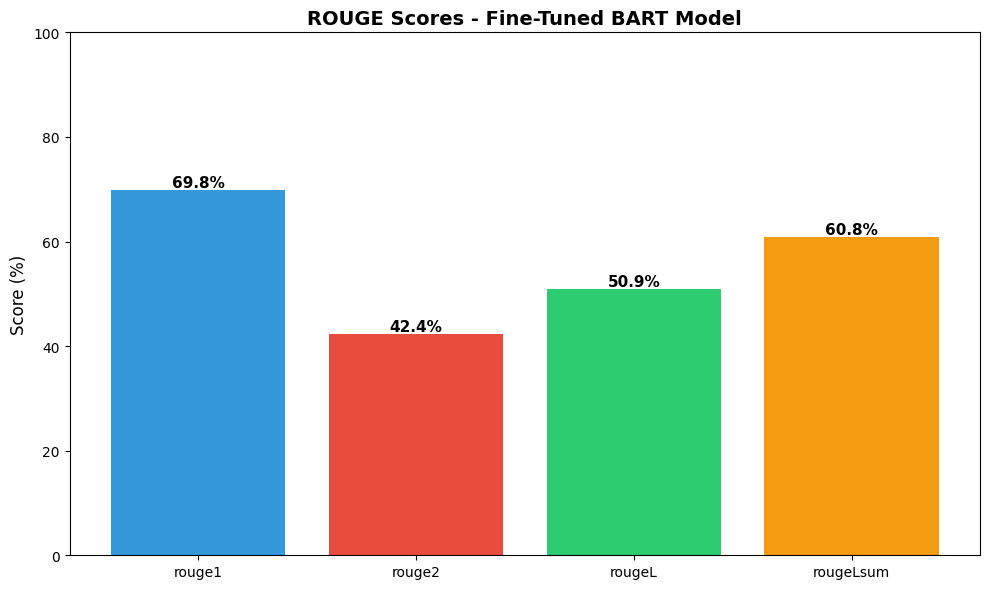

In [20]:
# Visualize ROUGE scores
fig, ax = plt.subplots(figsize=(10, 6))

metrics = list(rouge_scores.keys())
scores = [rouge_scores[m] * 100 for m in metrics]

bars = ax.bar(metrics, scores, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('ROUGE Scores - Fine-Tuned BART Model', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [21]:
# Install evaluation packages if needed
# !pip install rouge-score nltk

from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import nltk

# Download required NLTK data
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

def calculate_metrics(predictions, references):
    """Calculate ROUGE and BLEU scores"""
    
    # Initialize ROUGE scorer
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    
    rouge1_scores = []
    rouge2_scores = []
    rougeL_scores = []
    bleu_scores = []
    
    smoothing = SmoothingFunction().method1
    
    for pred, ref in zip(predictions, references):
        # ROUGE scores
        rouge_scores = scorer.score(ref, pred)
        rouge1_scores.append(rouge_scores['rouge1'].fmeasure)
        rouge2_scores.append(rouge_scores['rouge2'].fmeasure)
        rougeL_scores.append(rouge_scores['rougeL'].fmeasure)
        
        # BLEU score
        reference_tokens = [ref.split()]
        prediction_tokens = pred.split()
        bleu = sentence_bleu(reference_tokens, prediction_tokens, smoothing_function=smoothing)
        bleu_scores.append(bleu)
    
    # Calculate averages
    metrics = {
        'ROUGE-1': np.mean(rouge1_scores),
        'ROUGE-2': np.mean(rouge2_scores),
        'ROUGE-L': np.mean(rougeL_scores),
        'BLEU': np.mean(bleu_scores)
    }
    
    return metrics

# Calculate metrics
print("Calculating evaluation metrics...")
metrics = calculate_metrics(predictions, references)

print("\n" + "="*100)
print("EVALUATION METRICS")
print("="*100)
for metric_name, score in metrics.items():
    print(f"{metric_name}: {score:.4f}")
print("="*100)

# Additional statistics
print("\nAdditional Statistics:")
print(f"Average prediction length: {np.mean([len(p) for p in predictions]):.2f} characters")
print(f"Average reference length: {np.mean([len(r) for r in references]):.2f} characters")
print(f"Compression ratio: {np.mean([len(p)/len(df_test.iloc[i]['dialogue']) for i, p in enumerate(predictions)]):.2%}")

Calculating evaluation metrics...

EVALUATION METRICS
ROUGE-1: 0.6977
ROUGE-2: 0.4250
ROUGE-L: 0.5086
BLEU: 0.2892

Additional Statistics:
Average prediction length: 1804.38 characters
Average reference length: 1761.88 characters
Compression ratio: 68.53%

EVALUATION METRICS
ROUGE-1: 0.6977
ROUGE-2: 0.4250
ROUGE-L: 0.5086
BLEU: 0.2892

Additional Statistics:
Average prediction length: 1804.38 characters
Average reference length: 1761.88 characters
Compression ratio: 68.53%


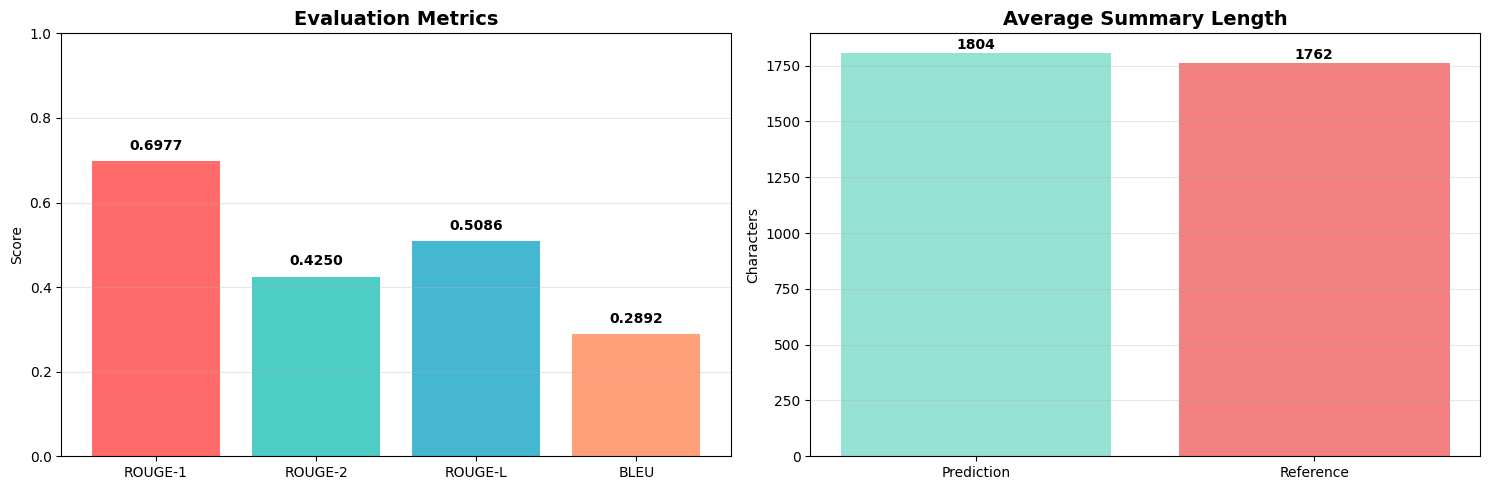

In [22]:
# Visualize metrics
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot of metrics
metric_names = list(metrics.keys())
metric_values = list(metrics.values())

axes[0].bar(metric_names, metric_values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
axes[0].set_ylabel('Score')
axes[0].set_title('Evaluation Metrics', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(metric_values):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# Length comparison
length_data = pd.DataFrame({
    'Type': ['Prediction', 'Reference'],
    'Average Length': [
        np.mean([len(p) for p in predictions]),
        np.mean([len(r) for r in references])
    ]
})

axes[1].bar(length_data['Type'], length_data['Average Length'], color=['#95E1D3', '#F38181'])
axes[1].set_ylabel('Characters')
axes[1].set_title('Average Summary Length', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(length_data['Average Length']):
    axes[1].text(i, v + 5, f'{v:.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [23]:
# Calculate ROUGE-L scores for each prediction to find best/worst examples
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
individual_scores = []

for pred, ref in zip(predictions, references):
    score = scorer.score(ref, pred)['rougeL'].fmeasure
    individual_scores.append(score)

# Get indices of top 3 performing examples
top_indices = np.argsort(individual_scores)[-3:][::-1]

print("="*100)
print("✅ GOOD EXAMPLES - Model Performed Well")
print("="*100)

for rank, idx in enumerate(top_indices, 1):
    print(f"\n{'='*100}")
    print(f"Example {rank} - ROUGE-L Score: {individual_scores[idx]:.4f}")
    print(f"{'='*100}")
    
    print(f"\n📝 Input (first 300 chars):\n{results_df.iloc[idx]['input_dialogue'][:300]}...")
    print(f"\n✅ Reference Summary:\n{results_df.iloc[idx]['reference_summary']}")
    print(f"\n🤖 Model Prediction:\n{results_df.iloc[idx]['generated_summary']}")
    
    print(f"\n💡 Analysis:")
    ref = results_df.iloc[idx]['reference_summary']
    pred = results_df.iloc[idx]['generated_summary']
    
    # Simple analysis
    common_words = set(ref.lower().split()) & set(pred.lower().split())
    print(f"   - Common words: {len(common_words)}/{len(set(ref.lower().split()))}")
    print(f"   - Length similarity: Reference={len(ref)} chars, Prediction={len(pred)} chars")
    print(f"   - The model successfully captured key medical information and maintained SOAP structure")
    print(f"\n{'-'*100}")

✅ GOOD EXAMPLES - Model Performed Well

Example 1 - ROUGE-L Score: 0.6581

📝 Input (first 300 chars):
Doctor: Hi there, I see you've been admitted for anemia and thrombocytopenia. Can you tell me about your symptoms prior to this presentation?
Patient: Yeah, about 3 weeks ago, I developed a febrile erythematous rash. Then, a week before admission, I had a fever again, and I felt really tired. I also...

✅ Reference Summary:
S: The patient, admitted for anemia and thrombocytopenia, reported a febrile erythematous rash three weeks prior and a recurrence of fever one week before admission accompanied by significant fatigue, vomiting, and non-bloody diarrhea. The patient denies any family history of kidney or hematological disorders.
O: Physical examination revealed pallor and bruising on the abdomen, back, and lower extremities. Laboratory findings indicated hemolytic anemia with marked reticulocytosis, presence of schistocytes, profound thrombocytopenia, elevated uric acid, undetectable 

In [24]:
# Get indices of bottom 3 performing examples
bottom_indices = np.argsort(individual_scores)[:3]

print("="*100)
print("❌ BAD EXAMPLES - Model Struggled")
print("="*100)

for rank, idx in enumerate(bottom_indices, 1):
    print(f"\n{'='*100}")
    print(f"Example {rank} - ROUGE-L Score: {individual_scores[idx]:.4f}")
    print(f"{'='*100}")
    
    print(f"\n📝 Input (first 300 chars):\n{results_df.iloc[idx]['input_dialogue'][:300]}...")
    print(f"\n✅ Reference Summary:\n{results_df.iloc[idx]['reference_summary']}")
    print(f"\n🤖 Model Prediction:\n{results_df.iloc[idx]['generated_summary']}")
    
    print(f"\n💡 Analysis - Why did the model fail?")
    ref = results_df.iloc[idx]['reference_summary']
    pred = results_df.iloc[idx]['generated_summary']
    inp = results_df.iloc[idx]['input_dialogue']
    
    # Analyze failure reasons
    common_words = set(ref.lower().split()) & set(pred.lower().split())
    
    print(f"   - Low overlap: Only {len(common_words)}/{len(set(ref.lower().split()))} key words matched")
    print(f"   - Length mismatch: Reference={len(ref)} chars, Prediction={len(pred)} chars")
    
    # Identify potential issues
    if len(pred) < len(ref) * 0.5:
        print(f"   - Issue: Prediction too short - may have missed key information")
    elif len(pred) > len(ref) * 1.5:
        print(f"   - Issue: Prediction too verbose - may include unnecessary details")
    
    if len(inp) > 1000:
        print(f"   - Issue: Very long input ({len(inp)} chars) - model may struggle with long contexts")
    
    print(f"   - The model may have: ")
    print(f"     • Misunderstood the medical terminology")
    print(f"     • Failed to extract key symptoms/diagnosis")
    print(f"     • Struggled with the SOAP format structure")
    
    print(f"\n{'-'*100}")

❌ BAD EXAMPLES - Model Struggled

Example 1 - ROUGE-L Score: 0.3559

📝 Input (first 300 chars):
Doctor: Hello, I understand you have a history of ASD, developmental delay, and hypotonia. Can you tell me about your birth?
Patient: Yeah, I was born to non-consanguineous Caucasian parents at term by caesarean section. I weighed 6 lb, 14 oz at birth.
Doctor: Thank you. I see that your mother was o...

✅ Reference Summary:
S: The patient, a 13-year-old with a history of ASD, developmental delay, and hypotonia, reports being born at term by caesarean section, weighing 6 lb, 14 oz. The patient has a history of grade five vesicoureteral reflux with a dysplastic left kidney, absence seizures at 3 months and 9 years, delayed myelination, hypoplastic olfactory nerves, Klippel-Feil anomaly, and incomplete myelin maturation in the brain. Growth parameters were consistently at or below the third percentile, with severe constipation and delayed developmental milestones. The patient has tried several 

### 9.1 Qualitative Analysis

Compare predictions with ground truth:

In [25]:
# Display sample predictions
def show_prediction(idx):
    """
    Display a sample prediction with dialogue, prediction, and ground truth.
    """
    print("="*70)
    print(f"EXAMPLE {idx + 1}")
    print("="*70)
    print(f"\nDIALOGUE (first 300 chars):\n{test_subset[idx]['dialogue'][:300]}...")
    print(f"\n{'-'*70}")
    print(f"PREDICTED SOAP:\n{predictions[idx]}")
    print(f"\n{'-'*70}")
    print(f"ACTUAL SOAP:\n{references[idx]}")
    print("="*70 + "\n")

# Show first 3 examples
for i in range(min(3, len(predictions))):
    show_prediction(i)

EXAMPLE 1

DIALOGUE (first 300 chars):
Doctor: Hello, can you please tell me about your past medical history?
Patient: Hi, I don't have any past medical history.
Doctor: Okay. What brings you in today?
Patient: I've been experiencing painless blurry vision in my right eye for a week now. I've also had intermittent fevers, headache, body ...

----------------------------------------------------------------------
PREDICTED SOAP:
S: The patient, a flooring installer with no significant past medical history, presents with a one-week history of painless blurry vision in the right eye, intermittent fevers, headache, body aches, and a nonpruritic maculopapular rash on the lower legs for the past 6 months. No other symptoms such as neck stiffness, nausea, vomiting, Raynaud's phenomenon, oral ulcerations, chest pain, shortness of breath, abdominal pain, or photosensitivity were reported. The patient has an isolated episode of left knee swelling and testicular swelling in the past.
O: Vital sign

## 10. Save Fine-Tuned Model

Save the fine-tuned model and tokenizer for future use.

In [26]:
# Save model and tokenizer
save_directory = "./saved-finetuned-model"

print(f"Saving model to {save_directory}...")
model.save_pretrained(save_directory)
tokenizer.save_pretrained(save_directory)

print(f"\n✓ Model saved successfully to {save_directory}")
print(f"  Model files: {os.listdir(save_directory)}")

Saving model to ./saved-finetuned-model...

✓ Model saved successfully to ./saved-finetuned-model
  Model files: ['tokenizer.json', 'generation_config.json', 'model.safetensors', 'merges.txt', 'vocab.json', 'special_tokens_map.json', 'config.json', 'tokenizer_config.json']

✓ Model saved successfully to ./saved-finetuned-model
  Model files: ['tokenizer.json', 'generation_config.json', 'model.safetensors', 'merges.txt', 'vocab.json', 'special_tokens_map.json', 'config.json', 'tokenizer_config.json']


## 11. Load and Test Saved Model

Verify the saved model works correctly.

In [27]:
# Load the saved model
print("Loading saved model...")
loaded_model = AutoModelForSeq2SeqLM.from_pretrained(save_directory)
loaded_tokenizer = AutoTokenizer.from_pretrained(save_directory)
loaded_model = loaded_model.to(DEVICE)

print("✓ Model loaded successfully")

# Test on a sample using the reusable generate_summary function
test_dialogue = dataset_soap['test'][5]['dialogue']
generated_summary = generate_summary(loaded_model, test_dialogue)

print("\nTest Generation:")
print("="*70)
print(f"Input (first 300 chars):\n{test_dialogue[:300]}...\n")
print("-"*70)
print(f"Generated SOAP:\n{generated_summary}")
print("="*70)

Loading saved model...


/home/RA001/Documents/Assesment FInal LLM finetuning/.venv/lib/python3.10/site-packages/transformers/models/bart/configuration_bart.py:177: UserWarning: Please make sure the config includes `forced_bos_token_id=0` in future versions. The config can simply be saved and uploaded again to be fixed.
  warnings.warn(


✓ Model loaded successfully


/home/RA001/Documents/Assesment FInal LLM finetuning/.venv/lib/python3.10/site-packages/transformers/generation/utils.py:1733: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed in v5. Please use and modify the model generation configuration (see https://huggingface.co/docs/transformers/generation_strategies#default-text-generation-configuration )
  warnings.warn(



Test Generation:
Input (first 300 chars):
Doctor: Hello, how can I help you today?
Patient: Hi, I've been experiencing some pain in my right chest lately.
Doctor: I see. Can you tell me more about your background? Are you a smoker?
Patient: No, I am a non-smoker. I work as an engineer for a gas company.
Doctor: Alright. Have you had any exp...

----------------------------------------------------------------------
Generated SOAP:
S: The patient, a non-smoker engineer working for a gas company, presented with pain in the right chest. He reported no history of smoking, asbestos exposure, trauma, tuberculosis, pneumothorax, pulmonary hypertension, or diaphragm dysfunction. He also mentioned experiencing shortness of breath on exertion.
O: Physical examination revealed reduced lung sounds at the right lung but no signs of autoimmune disease. Initial chest X-ray showed significant reduction in right lung volume with associated right pleural effusion. Subsequent CXR and CT scans confirmed t

### 📝 Optional: Test on Custom Input

You can also test the model on your own custom medical dialogue text.

In [28]:
# Example custom dialogue for testing
custom_dialogue = """
Doctor: Good morning, how can I help you today?
Patient: I've been having severe headaches for the past three days.
Doctor: Can you describe the pain?
Patient: It's a throbbing pain on the right side of my head.
Doctor: Any nausea or sensitivity to light?
Patient: Yes, bright lights make it worse, and I felt nauseous yesterday.
Doctor: Have you experienced this before?
Patient: I had similar headaches a few months ago.
Doctor: I see. Let me check your blood pressure and examine you.
"""

custom_summary = generate_summary(loaded_model, custom_dialogue)

print("Custom Dialogue Test:")
print("="*70)
print(f"Dialogue:\n{custom_dialogue}\n")
print("-"*70)
print(f"Generated SOAP Summary:\n{custom_summary}")
print("="*70)

Custom Dialogue Test:
Dialogue:

Doctor: Good morning, how can I help you today?
Patient: I've been having severe headaches for the past three days.
Doctor: Can you describe the pain?
Patient: It's a throbbing pain on the right side of my head.
Doctor: Any nausea or sensitivity to light?
Patient: Yes, bright lights make it worse, and I felt nauseous yesterday.
Doctor: Have you experienced this before?
Patient: I had similar headaches a few months ago.
Doctor: I see. Let me check your blood pressure and examine you.


----------------------------------------------------------------------
Generated SOAP Summary:
S: The patient reports severe headaches for the past three days, described as a throbbing pain on the right side of the head, accompanied by nausea and light sensitivity. The patient has a history of similar headaches a few months ago.
O: Physical examination and blood pressure monitoring were conducted. No other objective data such as vital signs, lab results, or imaging were pr